## Criteo dataset - exploratory data analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

### Reading data 

We read first 1 000 000 rows - just not for not burdening our RAMs

In [9]:
col_names = ['label'] + [f'I{i}' for i in range(1, 14)] + [f'C{i}' for i in range(1, 27)]
df = pd.read_csv('train.txt', sep='\t', names=col_names, nrows=1000000)
print(f"\nData shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")


Data shape: 1000000 rows, 40 columns.



In [10]:
print("Columns list:")
print(df.columns.tolist())
print("-" * 50)

print("\nStructure:")
df.info()

display(df.head())

Columns list:
['label', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26']
--------------------------------------------------

Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 40 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   label   1000000 non-null  int64  
 1   I1      576997 non-null   float64
 2   I2      1000000 non-null  int64  
 3   I3      764946 non-null   float64
 4   I4      750884 non-null   float64
 5   I5      975464 non-null   float64
 6   I6      778260 non-null   float64
 7   I7      959166 non-null   float64
 8   I8      999338 non-null   float64
 9   I9      959166 non-null   float64
 10  I10     576997 non-null   float64
 11  I11     959166 non-null   float64


,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,0,1.0,1,5.0,0.0,1382.0,4.0,15.0,2.0,181.0,1.0,2.0,NaN,2.0,68fd1e64,80e26c9b,fb936136,7b4723c4,25c83c98,7e0ccccf,de7995b8,1f89b562,a73ee510,a8cd5504,b2cb9c98,37c9c164,2824a5f6,1adce6ef,8ba8b39a,891b62e7,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,NaN,3a171ecb,c5c50484,e8b83407,9727dd16
1,0,2.0,0,44.0,1.0,102.0,8.0,2.0,2.0,4.0,1.0,1.0,NaN,4.0,68fd1e64,f0cf0024,6f67f7e5,41274cd7,25c83c98,fe6b92e5,922afcc0,0b153874,a73ee510,2b53e5fb,4f1b46f3,623049e6,d7020589,b28479f6,e6c5b5cd,c92f3b61,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
2,0,2.0,0,1.0,14.0,767.0,89.0,4.0,2.0,245.0,1.0,3.0,3.0,45.0,287e684f,0a519c5c,02cf9876,c18be181,25c83c98,7e0ccccf,c78204a1,0b153874,a73ee510,3b08e48b,5f5e6091,8fe001f4,aa655a2f,07d13a8f,6dc710ed,36103458,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
3,0,NaN,893,NaN,NaN,4392.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN,NaN,68fd1e64,2c16a946,a9a87e68,2e17d6f6,25c83c98,fe6b92e5,2e8a689b,0b153874,a73ee510,efea433b,e51ddf94,a30567ca,3516f6e6,07d13a8f,18231224,52b8680f,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
4,0,3.0,-1,NaN,0.0,2.0,0.0,3.0,0.0,0.0,1.0,1.0,NaN,0.0,8cf07265,ae46a29d,c81688bb,f922efad,25c83c98,13718bbd,ad9fa255,0b153874,a73ee510,5282c137,e5d8af57,66a76a26,f06c53ac,1adce6ef,8ff4b403,01adbab4,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN


### Analysis of a target variable `label` (click)

No click (0): 74.51%
Click (1): 25.49%



Text(0.5, 0, 'click')

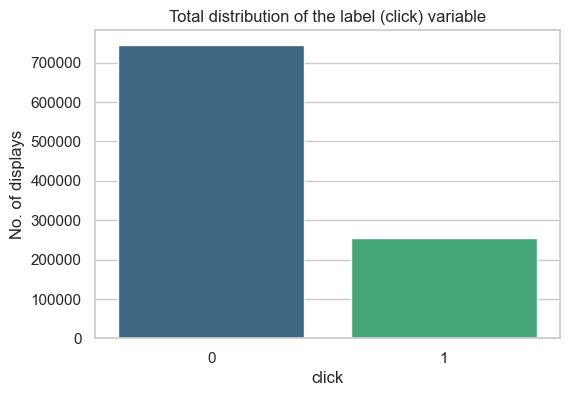

In [20]:
click_dist = df['label'].value_counts(normalize=True) * 100
print(f"No click (0): {click_dist[0]:.2f}%")
print(f"Click (1): {click_dist[1]:.2f}%\n")

plt.figure(figsize=(6, 4))
ax1 = sns.countplot(x='label', hue='label', data=df, palette='viridis', legend=False)
plt.title('Total distribution of the label (click) variable')
plt.ylabel('No. of displays')
plt.xlabel('click')  


### Missing data, numerical skewness 

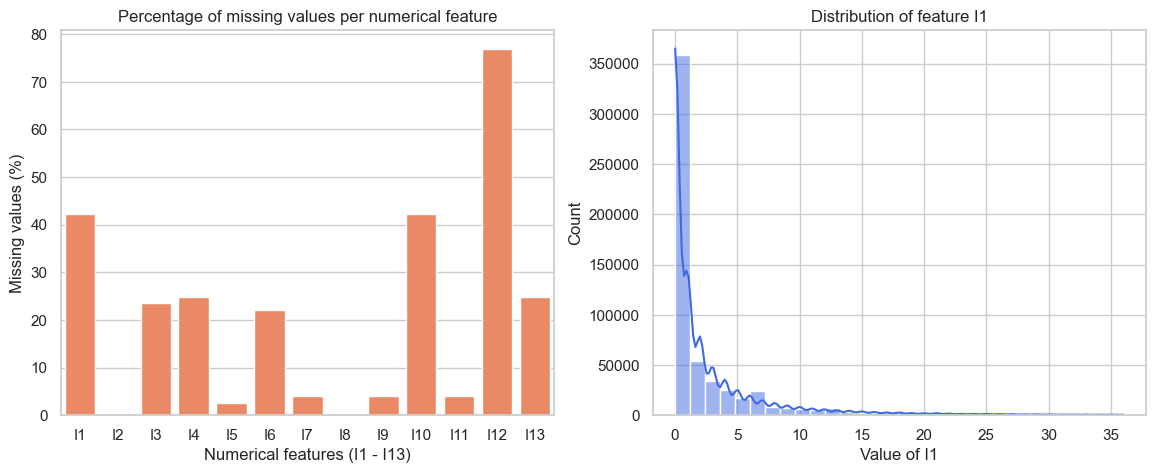

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot A: missing data 
num_cols = [f'I{i}' for i in range(1, 14)]
missing_percentages = (df[num_cols].isnull().sum() / len(df)) * 100

sns.barplot(x=missing_percentages.index, y=missing_percentages.values, ax=axes[0], color='coral')
axes[0].set_title('Percentage of missing values per numerical feature')
axes[0].set_ylabel('Missing values (%)')
axes[0].set_xlabel('Numerical features (I1 - I13)')


# plot B: skewness + filterng NaNs/ outliers
i1_data = df['I1'].dropna()
i1_data = i1_data[i1_data < i1_data.quantile(0.99)] 

sns.histplot(i1_data, bins=30, ax=axes[1], color='royalblue', kde=True)
axes[1].set_title('Distribution of feature I1')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Value of I1')


plt.show()